In [9]:
# Импорты и настройка путей
import sys
import os
sys.path.append(os.path.abspath('..'))

import pandas as pd
import numpy as np
import joblib

# Импорты из наших модулей
from src import load_data, split_data
from src import create_preprocessor
from src import train_and_select_model, save_model_and_preprocessor
from src import calculate_metrics, print_metrics_table, print_classification_report
from src import plot_confusion_matrix, plot_roc_curve

print("Все модули загружены успешно!")

Все модули загружены успешно!


In [10]:
# Загрузка и разделение данных
df = load_data('../data/train.csv')
print("Данные загружены:", df.shape)

X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_test, y_train, y_test = split_data(X, y, test_size=0.2, random_state=42)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки:  {X_test.shape}")
print(f"Баланс классов в train: {y_train.value_counts(normalize=True).to_dict()}")
print(f"Баланс классов в test:  {y_test.value_counts(normalize=True).to_dict()}")

Данные загружены: (891, 12)
Размер обучающей выборки: (712, 11)
Размер тестовой выборки:  (179, 11)
Баланс классов в train: {0: 0.6165730337078652, 1: 0.38342696629213485}
Баланс классов в test:  {0: 0.6145251396648045, 1: 0.3854748603351955}


In [11]:
# Предобработка
preprocessor = create_preprocessor()
X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(X_test)

print("Предобработка завершена.")
print(f"Размер train после предобработки: {X_train_prepared.shape}")
print(f"Размер test после предобработки:  {X_test_prepared.shape}")

Предобработка завершена.
Размер train после предобработки: (712, 13)
Размер test после предобработки:  (179, 13)


In [12]:
# Обучение и выбор лучшей модели
best_model, results, best_name = train_and_select_model(
    X_train_prepared, y_train,
    X_test_prepared, y_test
)

print(f"\nЛучшая модель: {best_name}")
print(f"Test ROC-AUC лучшей модели: {results[best_name]['test_roc_auc']:.4f}")


=== Training LogisticRegression ===
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Test ROC-AUC: 0.8482

=== Training RandomForest ===
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Test ROC-AUC: 0.8419

=== Training XGBoost ===
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Test ROC-AUC: 0.8341

Лучшая модель: LogisticRegression
Test ROC-AUC лучшей модели: 0.8482


In [13]:
# Сохранение модели и препроцессора
save_model_and_preprocessor(best_model, preprocessor, best_name)

Saved model and preprocessor to ../models/


=== Основные метрики ===
   Accuracy  Precision  Recall  F1-score  ROC-AUC
0    0.8156        0.8  0.6957    0.7442   0.8482

=== Детальный отчёт классификации ===
              precision    recall  f1-score   support

       Погиб       0.82      0.89      0.86       110
       Выжил       0.80      0.70      0.74        69

    accuracy                           0.82       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.81      0.82      0.81       179



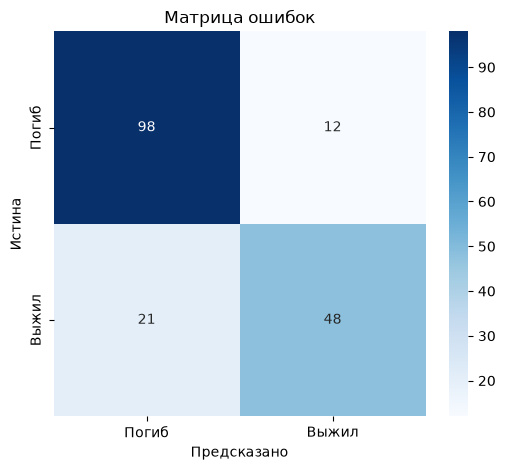

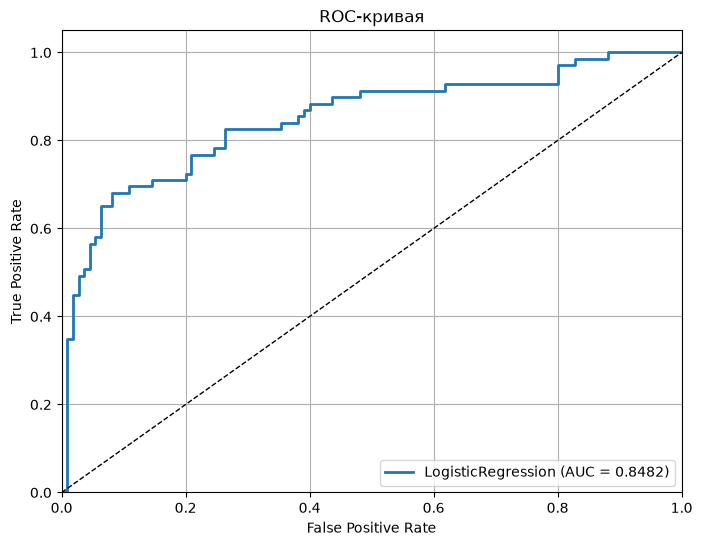

0.8482213438735178

In [14]:
# Детальная оценка лучшей модели
# Получаем предсказания
y_pred = best_model.predict(X_test_prepared)
y_pred_proba = best_model.predict_proba(X_test_prepared)[:, 1]

# Расчёт метрик
metrics = calculate_metrics(y_test, y_pred, y_pred_proba)
print_metrics_table(metrics)
print_classification_report(y_test, y_pred)

# Визуализация
plot_confusion_matrix(y_test, y_pred, labels=['Погиб', 'Выжил'])
plot_roc_curve(y_test, y_pred_proba, model_name=best_name)

In [15]:
# Сравнение всех моделей (таблица)
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'CV ROC-AUC': [results[m]['cv_roc_auc'] for m in results],
    'Test ROC-AUC': [results[m]['test_roc_auc'] for m in results],
    'Best Params': [str(results[m]['best_params']) for m in results]
})

print("\n=== Сравнение моделей ===")
print(comparison_df.to_string(index=False))


=== Сравнение моделей ===
             Model  CV ROC-AUC  Test ROC-AUC                                                                   Best Params
LogisticRegression    0.855593      0.848221                                  {'C': 0.1, 'l1_ratio': 0, 'solver': 'lbfgs'}
      RandomForest    0.871646      0.841897                 {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}
           XGBoost    0.878959      0.834124 {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}


In [16]:
# Проверка загруженной модели
loaded_model = joblib.load(f'../models/best_model_{best_name}.pkl')
loaded_preprocessor = joblib.load('../models/preprocessor.pkl')

X_test_prepared_loaded = loaded_preprocessor.transform(X_test)
y_pred_loaded = loaded_model.predict(X_test_prepared_loaded)

from sklearn.metrics import accuracy_score
print(f"Accuracy загруженной модели: {accuracy_score(y_test, y_pred_loaded):.4f}")
print("Модель успешно загружена и работает.")

Accuracy загруженной модели: 0.8156
Модель успешно загружена и работает.


In [17]:
# Сохранение предсказаний для Kaggle
from src import save_predictions

# Если хотите сохранить предсказания для submission (например, на тестовом наборе без меток)
# Здесь мы просто сохраняем предсказания на нашей тестовой выборке для демонстрации
save_predictions(y_pred_loaded, filepath='../submission.csv', ids=X_test.index)

Предсказания сохранены в ../submission.csv
